# Learned Layer Mixer: Attention-Based Layer Weighting for Speech Emotion Recognition

**Task 5: CSCI 535 Final Project**

Instead of selecting a single best layer for emotion classification (as in the frozen probing pipeline),
this notebook stacks ALL 25 layer representations (CNN + 24 transformer layers) and trains a lightweight
attention network that learns which layers matter most per dataset. After training, the learned attention
weights reveal which layers the model chose to emphasize, providing independent confirmation of the
layer-wise probing findings.

**Architecture**: `LayerMixer(nn.Module)`: Linear(hidden_dim, 1) -> softmax over layers -> weighted sum -> Linear classifier
**Evaluation**: 5-fold stratified cross-validation (same as probing pipeline)
**Data**: Pre-extracted frozen hidden states from Nima's EXP3 run, 6 models x 7 datasets = 42 clean experiments.

Models: wav2vec2, HuBERT, Whisper, WavLM, MERT, w2v-BERT
Datasets: RAVDESS, EmoDB, IEMOCAP, SAVEE, AESDD, MESD, MSP-Podcast (4-class Test1)


In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Configuration & Path Resolution

The EXP3 hidden state files are split across two top-level folders (Google Drive splits large downloads).  
Labels and CSVs are all in `EXP3 2/`. When Nima sends WavLM/MERT/w2v-BERT files, just add them to `MODELS` and drop the .npy files in `EXP3 2/embeddings/`.

In [2]:
import os
import re
import tempfile
from collections import defaultdict
from pathlib import Path

# ============================================================
# PROJECT PATHS
# ============================================================
def _detect_project_root():
    env_root = os.environ.get('CSCI535_SER_PROJECT_ROOT')
    candidates = []
    if env_root:
        candidates.append(Path(env_root).expanduser())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])

    for candidate in candidates:
        has_notebook = (candidate / 'my_code' / 'layer_mixer.ipynb').exists()
        has_data = any((candidate / part).exists() for part in ('embeddings_npyfiles', 'EXP3', 'EXP3 2'))
        if has_notebook and has_data:
            return str(candidate)

    raise FileNotFoundError(
        'Could not detect project root. Set CSCI535_SER_PROJECT_ROOT to the repo root before running this notebook.'
    )

def _detect_output_root(project_root):
    env_root = os.environ.get('CSCI535_SER_OUTPUT_ROOT')
    candidates = []
    if env_root:
        candidates.append(Path(env_root).expanduser())

    candidates.append(Path(project_root))

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.append(Path(tempfile.gettempdir()) / Path(project_root).name)

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if str(candidate) in seen:
            continue
        seen.add(str(candidate))
        try:
            candidate.mkdir(parents=True, exist_ok=True)
            probe = candidate / '.layer_mixer_write_test'
            probe.write_text('ok')
            probe.unlink()
            return str(candidate)
        except OSError:
            continue

    raise OSError(
        'Could not find a writable output root. Set CSCI535_SER_OUTPUT_ROOT to a writable directory before running this notebook.'
    )


PROJECT_ROOT = _detect_project_root()
OUTPUT_ROOT = _detect_output_root(PROJECT_ROOT)
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'OUTPUT_ROOT:  {OUTPUT_ROOT}')

# Nima's full drop: 22 split "Embedding-Files*" folders, each with
#   clean-embeddings/embeddings/*.npy   (6 models x 7 datasets)
#   noisy-embeddings/embeddings/*.npy   (3 models x 7 datasets x 5 SNRs)
NIMA_EMBEDDINGS_ROOT = os.path.join(PROJECT_ROOT, 'embeddings_npyfiles')

# Legacy EXP3 folders from the first drop, kept only as fallback
EXP3_DIR = os.path.join(PROJECT_ROOT, 'EXP3', 'embeddings')
EXP3_2_DIR = os.path.join(PROJECT_ROOT, 'EXP3 2', 'embeddings')
LEGACY_CSV_DIR = os.path.join(PROJECT_ROOT, 'EXP3 2', 'csv')

# Nima's TASK1-2-8 baseline probing results (new format: per-model CSV with Dataset column)
NIMA_CLEAN_CSV_DIR = os.path.join(PROJECT_ROOT, 'TASK1-2-8', 'clean-summary', 'csv')
NIMA_NOISY_CSV_DIR = os.path.join(PROJECT_ROOT, 'TASK1-2-8', 'noisy-summary', 'csv')
NIMA_MSP_4VS8_CSV = os.path.join(
    PROJECT_ROOT, 'TASK1-2-8', 'comparison-4vs8-msp-podcast', 'csv', 'comparison_4vs8_master.csv'
)

RESULTS_DIR = os.path.join(OUTPUT_ROOT, 'my_code', 'results', 'layer_mixer')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# MODELS & DATASETS, 6 models x 7 datasets = 42 clean experiments
# ============================================================
MODELS = ['wav2vec2', 'HuBERT', 'Whisper', 'WavLM', 'MERT', 'w2v-BERT']
DATASETS = ['RAVDESS', 'EmoDB', 'IEMOCAP', 'SAVEE', 'AESDD', 'MESD', 'MSP-Podcast']

# MSP-Podcast uses the 4-class Test1 filter (anger/happiness/neutral/sadness).
# Nima's labels .npy files are already filtered, so no special loading logic needed.
MSP_PODCAST_NAME = 'MSP-Podcast'

# ============================================================
# GLOBAL FILE INDEX, walk all Embedding-Files splits once at startup
# ============================================================
# Naming convention (from Nima's feature extractor):
#   {hidden_states|filenames|labels}_{Model}_{Dataset}[_SNR{N}].npy
# Examples:
#   hidden_states_WavLM_MSP-Podcast.npy           (clean)
#   hidden_states_HuBERT_RAVDESS_SNR10.npy        (noisy)
_EMB_PATTERN = re.compile(
    r"^(hidden_states|filenames|labels)_([A-Za-z0-9\-]+)_([A-Za-z0-9\-]+?)(?:_SNR(\d+))?\.npy$"
)


def _build_embedding_index(verbose=False):
    """Walk every Embedding-Files* split + legacy EXP3 folders once and return
        {(prefix, model, dataset, snr): abspath}
    prefix in {'hidden_states','filenames','labels'}, snr is 'clean' or 'SNR{N}'.
    """
    index = {}

    # 1. Nima's big drop (22 split folders)
    if os.path.isdir(NIMA_EMBEDDINGS_ROOT):
        for top in sorted(os.listdir(NIMA_EMBEDDINGS_ROOT)):
            if not top.startswith('Embedding-Files'):
                continue
            top_path = os.path.join(NIMA_EMBEDDINGS_ROOT, top)
            if not os.path.isdir(top_path):
                continue
            for sub in ('clean-embeddings', 'noisy-embeddings'):
                emb_dir = os.path.join(top_path, sub, 'embeddings')
                if not os.path.isdir(emb_dir):
                    continue
                for fname in os.listdir(emb_dir):
                    if not fname.endswith('.npy'):
                        continue
                    m = _EMB_PATTERN.match(fname)
                    if not m:
                        continue
                    prefix, model, dataset, snr = (
                        m.group(1),
                        m.group(2),
                        m.group(3),
                        f'SNR{m.group(4)}' if m.group(4) else 'clean',
                    )
                    key = (prefix, model, dataset, snr)
                    if key not in index:  # splits are partitioned, first-found is fine
                        index[key] = os.path.join(emb_dir, fname)

    # 2. Legacy EXP3 folders, only fills gaps (earlier drop, 3 models)
    for legacy_dir in (EXP3_2_DIR, EXP3_DIR):
        if not os.path.isdir(legacy_dir):
            continue
        for fname in os.listdir(legacy_dir):
            if not fname.endswith('.npy'):
                continue
            m = _EMB_PATTERN.match(fname)
            if not m:
                continue
            prefix, model, dataset, snr = (
                m.group(1),
                m.group(2),
                m.group(3),
                f'SNR{m.group(4)}' if m.group(4) else 'clean',
            )
            key = (prefix, model, dataset, snr)
            if key not in index:
                index[key] = os.path.join(legacy_dir, fname)

    if verbose:
        by_prefix = defaultdict(lambda: [0, 0])  # prefix -> [clean, noisy]
        for (prefix, model, dataset, snr), _ in index.items():
            by_prefix[prefix][0 if snr == 'clean' else 1] += 1
        print(f"Indexed {len(index)} .npy files across all folders")
        for prefix in ('hidden_states', 'filenames', 'labels'):
            clean_n, noisy_n = by_prefix[prefix]
            print(f"  {prefix:>14}  clean={clean_n:<4} noisy={noisy_n:<4}")

    return index


EMB_INDEX = _build_embedding_index(verbose=True)


# ============================================================
# PATH RESOLUTION
# ============================================================
def resolve_hidden_states_path(model, dataset, snr='clean'):
    """Return the abspath of hidden_states .npy for (model, dataset, snr)."""
    key = ('hidden_states', model, dataset, snr)
    if key in EMB_INDEX:
        return EMB_INDEX[key]
    raise FileNotFoundError(
        f"Missing hidden_states: model={model} dataset={dataset} snr={snr}"
    )


def resolve_labels_path(model, dataset, snr='clean'):
    """Labels are dataset-specific, the same vector is reused across every model
    that embedded that dataset. Prefer (model, dataset) labels; fall back to any
    other model's labels at the same SNR if the preferred file is missing.
    """
    key = ('labels', model, dataset, snr)
    if key in EMB_INDEX:
        return EMB_INDEX[key]
    for other in MODELS:
        fkey = ('labels', other, dataset, snr)
        if fkey in EMB_INDEX:
            return EMB_INDEX[fkey]
    raise FileNotFoundError(f"Missing labels: dataset={dataset} snr={snr}")


# ============================================================
# PLOT STYLE, matches Nima's post_train.py exactly
# ============================================================
PLOT_STYLE = {
    'accuracy_color': '#2196F3',
    'f1_color': '#FF5722',
    'accuracy_marker': 'o',
    'f1_marker': 's',
    'linewidth': 2,
    'figsize_single': (10, 5),
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_fontsize': 10,
    'legend_fontsize': 11,
    'grid_alpha': 0.3,
    'dpi': 300,
}
LAYER_LABELS = ['CNN'] + [str(i) for i in range(1, 25)]

# Training hyperparameters, matched to Nima's probing pipeline (train.py)
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 50
PATIENCE = 10
N_SPLITS = 5
RANDOM_STATE = 42

print()
print(f"Models   ({len(MODELS)}): {MODELS}")
print(f"Datasets ({len(DATASETS)}): {DATASETS}")
print(f"Total clean experiments: {len(MODELS) * len(DATASETS)}")


Indexed 378 .npy files across all folders
   hidden_states  clean=42   noisy=84  
       filenames  clean=42   noisy=84  
          labels  clean=42   noisy=84  

Models   (6): ['wav2vec2', 'HuBERT', 'Whisper', 'WavLM', 'MERT', 'w2v-BERT']
Datasets (7): ['RAVDESS', 'EmoDB', 'IEMOCAP', 'SAVEE', 'AESDD', 'MESD', 'MSP-Podcast']
Total clean experiments: 42


## 2. Load & Verify All Embeddings

Load every model-dataset combination's hidden states and labels. Print shapes to verify integrity.

In [3]:
# Load all embeddings and labels
data = {}
print(f"{'Model':<12} {'Dataset':<12} {'Hidden States Shape':<25} {'Labels Shape':<15} {'Classes'}")
print("-" * 80)

for model in MODELS:
    for dataset in DATASETS:
        try:
            hs_path = resolve_hidden_states_path(model, dataset)
            lb_path = resolve_labels_path(model, dataset)
            
            hidden_states = np.load(hs_path)
            labels_raw = np.load(lb_path, allow_pickle=True)
            
            # Encode string labels to integers
            le = LabelEncoder()
            labels_encoded = le.fit_transform(labels_raw)
            num_classes = len(le.classes_)
            
            data[(model, dataset)] = {
                'hidden_states': hidden_states,
                'labels': labels_encoded,
                'label_encoder': le,
                'num_classes': num_classes,
            }
            
            print(f"{model:<12} {dataset:<12} {str(hidden_states.shape):<25} {str(labels_raw.shape):<15} {num_classes} {list(le.classes_)}")
        except FileNotFoundError as e:
            print(f"{model:<12} {dataset:<12} *** MISSING: {e}")

print(f"\nLoaded {len(data)}/{len(MODELS)*len(DATASETS)} experiments successfully.")

Model        Dataset      Hidden States Shape       Labels Shape    Classes
--------------------------------------------------------------------------------
wav2vec2     RAVDESS      (2316, 25, 1024)          (2316,)         8 [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
wav2vec2     EmoDB        (535, 25, 1024)           (535,)          6 [np.str_('bored'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


wav2vec2     IEMOCAP      (5460, 25, 1024)          (5460,)         4 [np.str_('ang'), np.str_('hap'), np.str_('neu'), np.str_('sad')]
wav2vec2     SAVEE        (480, 25, 1024)           (480,)          7 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness'), np.str_('surprise')]
wav2vec2     AESDD        (604, 25, 1024)           (604,)          5 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('sadness')]
wav2vec2     MESD         (862, 25, 1024)           (862,)          6 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]


wav2vec2     MSP-Podcast  (10779, 25, 1024)         (10779,)        4 [np.str_('anger'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]


HuBERT       RAVDESS      (2316, 25, 1024)          (2316,)         8 [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
HuBERT       EmoDB        (535, 25, 1024)           (535,)          6 [np.str_('bored'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
HuBERT       IEMOCAP      (5460, 25, 1024)          (5460,)         4 [np.str_('ang'), np.str_('hap'), np.str_('neu'), np.str_('sad')]


HuBERT       SAVEE        (480, 25, 1024)           (480,)          7 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness'), np.str_('surprise')]
HuBERT       AESDD        (604, 25, 1024)           (604,)          5 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('sadness')]
HuBERT       MESD         (862, 25, 1024)           (862,)          6 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]


...

MERT         RAVDESS      (2316, 25, 1024)          (2316,)         8 [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
MERT         EmoDB        (535, 25, 1024)           (535,)          6 [np.str_('bored'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


MERT         IEMOCAP      (5460, 25, 1024)          (5460,)         4 [np.str_('ang'), np.str_('hap'), np.str_('neu'), np.str_('sad')]
MERT         SAVEE        (480, 25, 1024)           (480,)          7 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness'), np.str_('surprise')]
MERT         AESDD        (604, 25, 1024)           (604,)          5 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('sadness')]
MERT         MESD         (862, 25, 1024)           (862,)          6 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]


MERT         MSP-Podcast  (10779, 25, 1024)         (10779,)        4 [np.str_('anger'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]
w2v-BERT     RAVDESS      (2316, 25, 1024)          (2316,)         8 [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
w2v-BERT     EmoDB        (535, 25, 1024)           (535,)          6 [np.str_('bored'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


w2v-BERT     IEMOCAP      (5460, 25, 1024)          (5460,)         4 [np.str_('ang'), np.str_('hap'), np.str_('neu'), np.str_('sad')]
w2v-BERT     SAVEE        (480, 25, 1024)           (480,)          7 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness'), np.str_('surprise')]
w2v-BERT     AESDD        (604, 25, 1024)           (604,)          5 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('sadness')]
w2v-BERT     MESD         (862, 25, 1024)           (862,)          6 [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]


w2v-BERT     MSP-Podcast  (10779, 25, 1024)         (10779,)        4 [np.str_('anger'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]

Loaded 42/42 experiments successfully.


## 3. LayerMixer Model

The architecture from the project context document:
- **Attention**: `nn.Linear(hidden_dim, 1)` computes a per-layer score, softmax normalizes across layers
- **Classifier**: `nn.Linear(hidden_dim, num_classes)` on the weighted combination
- Attention weights are **input-dependent**: each sample gets its own layer weighting

In [4]:
class LayerMixer(nn.Module):
    """Learns attention weights over stacked transformer layer representations."""
    
    def __init__(self, num_layers, hidden_dim, num_classes):
        super().__init__()
        self.layer_weights = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        # x shape: (batch, num_layers, hidden_dim)
        attn = self.layer_weights(x).squeeze(-1)   # (batch, num_layers)
        attn = F.softmax(attn, dim=1)               # (batch, num_layers)
        mixed = torch.bmm(attn.unsqueeze(1), x)     # (batch, 1, hidden_dim)
        mixed = mixed.squeeze(1)                     # (batch, hidden_dim)
        logits = self.classifier(mixed)              # (batch, num_classes)
        return logits, attn

# Quick shape test
test_model = LayerMixer(num_layers=25, hidden_dim=1024, num_classes=8)
test_input = torch.randn(4, 25, 1024)
test_logits, test_attn = test_model(test_input)
print(f"Input:   {test_input.shape}")
print(f"Logits:  {test_logits.shape}")
print(f"Weights: {test_attn.shape}")
print(f"Weights sum to 1: {test_attn.sum(dim=1)}")
del test_model, test_input, test_logits, test_attn

Input:   torch.Size([4, 25, 1024])
Logits:  torch.Size([4, 8])
Weights: torch.Size([4, 25])


Weights sum to 1: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


## 4. Training Function

5-fold stratified CV with early stopping. Matches the evaluation methodology from the frozen probing pipeline (`train.py`).  
Returns per-fold metrics + the learned attention weights averaged across all validation samples.

In [5]:
def train_mixer(hidden_states, labels, num_classes, model_name, dataset_name):
    """
    Train LayerMixer with 5-fold stratified CV.
    
    Args:
        hidden_states: np.array (num_samples, 25, hidden_dim)
        labels: np.array (num_samples,) integer-encoded
        num_classes: int
        model_name: str (for logging)
        dataset_name: str (for logging)
    
    Returns:
        dict with mean_acc, std_acc, mean_f1, std_f1, attention_weights (25,)
    """
    num_layers, hidden_dim = hidden_states.shape[1], hidden_states.shape[2]
    
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    
    fold_accs, fold_f1s = [], []
    all_attn_weights = []  # collect attention weights from all val samples
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(hidden_states, labels)):
        # Split data
        X_train = torch.FloatTensor(hidden_states[train_idx]).to(DEVICE)
        y_train = torch.LongTensor(labels[train_idx]).to(DEVICE)
        X_val = torch.FloatTensor(hidden_states[val_idx]).to(DEVICE)
        y_val = torch.LongTensor(labels[val_idx]).to(DEVICE)
        
        train_ds = TensorDataset(X_train, y_train)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        
        # Init model
        model = LayerMixer(num_layers, hidden_dim, num_classes).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.CrossEntropyLoss()
        
        # Training with early stopping
        best_val_acc = 0.0
        patience_counter = 0
        best_state = None
        
        for epoch in range(EPOCHS):
            model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                logits, _ = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_logits, val_attn = model(X_val)
                val_preds = val_logits.argmax(dim=1).cpu().numpy()
                val_acc = accuracy_score(y_val.cpu().numpy(), val_preds)
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    break
        
        # Load best model and evaluate
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            val_logits, val_attn = model(X_val)
            val_preds = val_logits.argmax(dim=1).cpu().numpy()
            val_true = y_val.cpu().numpy()
        
        fold_acc = accuracy_score(val_true, val_preds)
        fold_f1 = f1_score(val_true, val_preds, average='weighted')
        fold_accs.append(fold_acc)
        fold_f1s.append(fold_f1)
        
        # Collect attention weights (average over val samples for this fold)
        fold_attn = val_attn.cpu().numpy().mean(axis=0)  # (25,)
        all_attn_weights.append(fold_attn)
        
        # Free GPU memory
        del X_train, y_train, X_val, y_val, model
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
    
    mean_attn = np.mean(all_attn_weights, axis=0)  # (25,)
    
    result = {
        'mean_acc': np.mean(fold_accs),
        'std_acc': np.std(fold_accs),
        'mean_f1': np.mean(fold_f1s),
        'std_f1': np.std(fold_f1s),
        'attention_weights': mean_attn,
        'fold_accs': fold_accs,
        'fold_f1s': fold_f1s,
    }
    
    print(f"  {model_name:>10} | {dataset_name:<10} | "
          f"Acc: {result['mean_acc']:.4f}±{result['std_acc']:.4f} | "
          f"F1: {result['mean_f1']:.4f}±{result['std_f1']:.4f} | "
          f"Top layer: {LAYER_LABELS[np.argmax(mean_attn)]} ({mean_attn.max():.3f})")
    
    return result

print("train_mixer() defined.")

train_mixer() defined.


## 5. Run All Experiments

Train LayerMixer on every model-dataset combination. This is the main compute cell, takes ~5-10 min on MPS.

In [6]:
results = {}

print(f"{'Model':>10} | {'Dataset':<10} | {'Accuracy':<20} | {'F1':<20} | Top Layer")
print("-" * 85)

for model in MODELS:
    for dataset in DATASETS:
        key = (model, dataset)
        if key not in data:
            print(f"  {model:>10} | {dataset:<10} | *** SKIPPED (missing data)")
            continue
        
        hs = data[key]['hidden_states']
        lb = data[key]['labels']
        nc = data[key]['num_classes']
        
        results[key] = train_mixer(hs, lb, nc, model, dataset)

print(f"\nCompleted {len(results)} experiments.")

     Model | Dataset    | Accuracy             | F1                   | Top Layer
-------------------------------------------------------------------------------------


    wav2vec2 | RAVDESS    | Acc: 0.8804±0.0198 | F1: 0.8797±0.0209 | Top layer: 8 (0.864)


    wav2vec2 | EmoDB      | Acc: 0.8972±0.0334 | F1: 0.8962±0.0316 | Top layer: 23 (0.163)


    wav2vec2 | IEMOCAP    | Acc: 0.6733±0.0194 | F1: 0.6721±0.0194 | Top layer: 4 (0.356)


    wav2vec2 | SAVEE      | Acc: 0.6167±0.0490 | F1: 0.6000±0.0562 | Top layer: 2 (0.323)


...

    w2v-BERT | IEMOCAP    | Acc: 0.6993±0.0228 | F1: 0.6983±0.0245 | Top layer: 17 (0.525)


    w2v-BERT | SAVEE      | Acc: 0.6583±0.0998 | F1: 0.6460±0.1069 | Top layer: 18 (0.673)


    w2v-BERT | AESDD      | Acc: 0.8907±0.0249 | F1: 0.8900±0.0254 | Top layer: 17 (0.445)


    w2v-BERT | MESD       | Acc: 0.8203±0.0435 | F1: 0.8206±0.0422 | Top layer: 5 (0.476)


    w2v-BERT | MSP-Podcast | Acc: 0.6717±0.0027 | F1: 0.6403±0.0030 | Top layer: 17 (0.260)

Completed 42 experiments.


## 6. Load Baseline Probing Results & Compare

Load the frozen probing CSVs (from EXP3) and compare: does the learned mixer beat the best single layer?

In [7]:
# Load baseline probing results from Nima's per-model clean-summary CSVs.
# If those are unavailable, fall back to the older EXP3 per-dataset CSVs.
# ------------------------------------------------------------
def _baseline_entry_from_df(df):
    df = df.sort_values('Layer_Num').reset_index(drop=True)
    best_idx = df['Accuracy'].idxmax()
    return {
        'best_layer': int(df.loc[best_idx, 'Layer_Num']),
        'best_layer_name': df.loc[best_idx, 'Layer'],
        'best_acc': float(df.loc[best_idx, 'Accuracy']),
        'best_f1': float(df.loc[best_idx, 'Weighted_F1']),
        'all_acc': df['Accuracy'].values,
        'all_f1': df['Weighted_F1'].values,
    }


def _load_baseline_df(model, dataset):
    summary_path = os.path.join(NIMA_CLEAN_CSV_DIR, f'{model}_summary.csv')
    if os.path.exists(summary_path):
        df_full = pd.read_csv(summary_path)
        if 'Dataset' in df_full.columns:
            df = df_full[df_full['Dataset'] == dataset].copy()
            if len(df):
                return df, f'clean-summary:{os.path.basename(summary_path)}'

    if dataset == MSP_PODCAST_NAME and os.path.exists(NIMA_MSP_4VS8_CSV):
        df_full = pd.read_csv(NIMA_MSP_4VS8_CSV)
        if 'Model' in df_full.columns:
            df = df_full[df_full['Model'] == model].copy()
            if 'SNR' in df.columns:
                df = df[df['SNR'].astype(str).str.lower() == 'clean'].copy()
            if len(df):
                return df, f'msp-4vs8:{os.path.basename(NIMA_MSP_4VS8_CSV)}'

    legacy_path = os.path.join(LEGACY_CSV_DIR, f'results_{model}_{dataset}.csv')
    if os.path.exists(legacy_path):
        return pd.read_csv(legacy_path), f'legacy:{os.path.basename(legacy_path)}'

    return None, ''


baseline = {}
baseline_sources = defaultdict(int)
missing_baselines = []

for model in MODELS:
    for dataset in DATASETS:
        df, source = _load_baseline_df(model, dataset)
        if df is None or len(df) == 0:
            missing_baselines.append((model, dataset))
            continue

        baseline[(model, dataset)] = _baseline_entry_from_df(df)
        baseline_sources[source] += 1

if baseline_sources:
    print('Baseline sources:')
    for source, count in sorted(baseline_sources.items()):
        print(f'  {source:<45} {count}')

if missing_baselines:
    print("Missing (model, dataset) baselines:", missing_baselines)

print(f"Loaded baselines for {len(baseline)} / {len(MODELS) * len(DATASETS)} combos\n")

# Build comparison table: mixer vs best-single-layer probe
rows = []
for model in MODELS:
    for dataset in DATASETS:
        key = (model, dataset)
        if key not in results:
            continue
        r = results[key]
        b = baseline.get(key)
        if b is None:
            continue

        delta_acc = r['mean_acc'] - b['best_acc']
        delta_f1 = r['mean_f1'] - b['best_f1']
        top_attn_layer = int(np.argmax(r['attention_weights']))

        rows.append({
            'Model': model,
            'Dataset': dataset,
            'Best_Probe_Layer': b['best_layer_name'],
            'Probe_Acc': f"{b['best_acc']:.4f}",
            'Mixer_Acc': f"{r['mean_acc']:.4f}\u00b1{r['std_acc']:.4f}",
            'Delta_Acc': f"{delta_acc:+.4f}",
            'Probe_F1': f"{b['best_f1']:.4f}",
            'Mixer_F1': f"{r['mean_f1']:.4f}\u00b1{r['std_f1']:.4f}",
            'Delta_F1': f"{delta_f1:+.4f}",
            'Top_Attn_Layer': LAYER_LABELS[top_attn_layer],
        })

comparison_df = pd.DataFrame(rows)

comparison_path = os.path.join(RESULTS_DIR, 'mixer_vs_probing_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"Saved: {comparison_path}\n")

print(comparison_df.to_string(index=False))


Loaded baselines for 42 / 42 combos

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/mixer_vs_probing_comparison.csv

   Model     Dataset Best_Probe_Layer Probe_Acc     Mixer_Acc Delta_Acc Probe_F1      Mixer_F1 Delta_F1 Top_Attn_Layer
wav2vec2     RAVDESS          Layer 8    0.9577 0.8804±0.0198   -0.0773   0.9578 0.8797±0.0209  -0.0781              8
wav2vec2       EmoDB          Layer 7    0.9757 0.8972±0.0334   -0.0785   0.9756 0.8962±0.0316  -0.0794             23
wav2vec2     IEMOCAP          Layer 8    0.6416 0.6733±0.0194   +0.0317   0.6412 0.6721±0.0194  +0.0309              4
wav2vec2       SAVEE         Layer 13    0.8583 0.6167±0.0490   -0.2416   0.8570 0.6000±0.0562  -0.2570              2
wav2vec2       AESDD          Layer 6    0.9305 0.9090±0.0103   -0.0215   0.9304 0.9077±0.0109  -0.0227              7
wav2vec2        MESD          Layer 5    0.8608 0.8167±0.0283   -0.0441   0.8599 0.8169±0.0289  -0.0430              6
wav2vec2 M

## 7. Attention Weight Heatmaps

One heatmap per model: rows = datasets, columns = layers (CNN, 1-24). Color intensity = learned attention weight.  
This is the key visualization, it shows which layers the mixer chose to emphasize for each dataset.

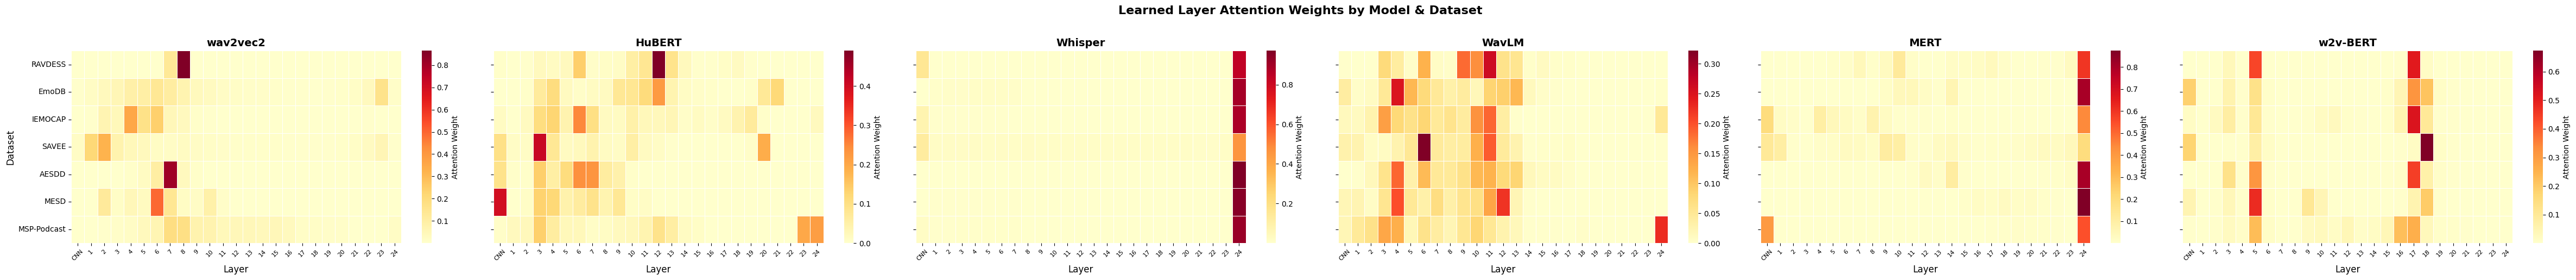

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/attention_heatmap_all_models.png


In [8]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(8 * len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    
    # Build attention matrix: datasets x layers
    attn_matrix = []
    dataset_labels = []
    for dataset in DATASETS:
        key = (model, dataset)
        if key in results:
            attn_matrix.append(results[key]['attention_weights'])
            dataset_labels.append(dataset)
    
    if not attn_matrix:
        continue
    
    attn_matrix = np.array(attn_matrix)  # (num_datasets, 25)
    
    sns.heatmap(
        attn_matrix,
        ax=ax,
        xticklabels=LAYER_LABELS,
        yticklabels=dataset_labels,
        cmap='YlOrRd',
        annot=False,
        fmt='.3f',
        cbar_kws={'label': 'Attention Weight'},
        linewidths=0.5,
    )
    ax.set_title(f'{model}', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
    ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
    if idx == 0:
        ax.set_ylabel('Dataset', fontsize=PLOT_STYLE['label_fontsize'])
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=PLOT_STYLE['tick_fontsize'])

plt.suptitle('Learned Layer Attention Weights by Model & Dataset',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

heatmap_path = os.path.join(RESULTS_DIR, 'attention_heatmap_all_models.png')
plt.savefig(heatmap_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {heatmap_path}")

## 8. Per-Dataset Attention Bar Charts

For each dataset, show per-layer attention weights for all models side-by-side. Reveals whether different models attend to the same layers for the same emotion set.

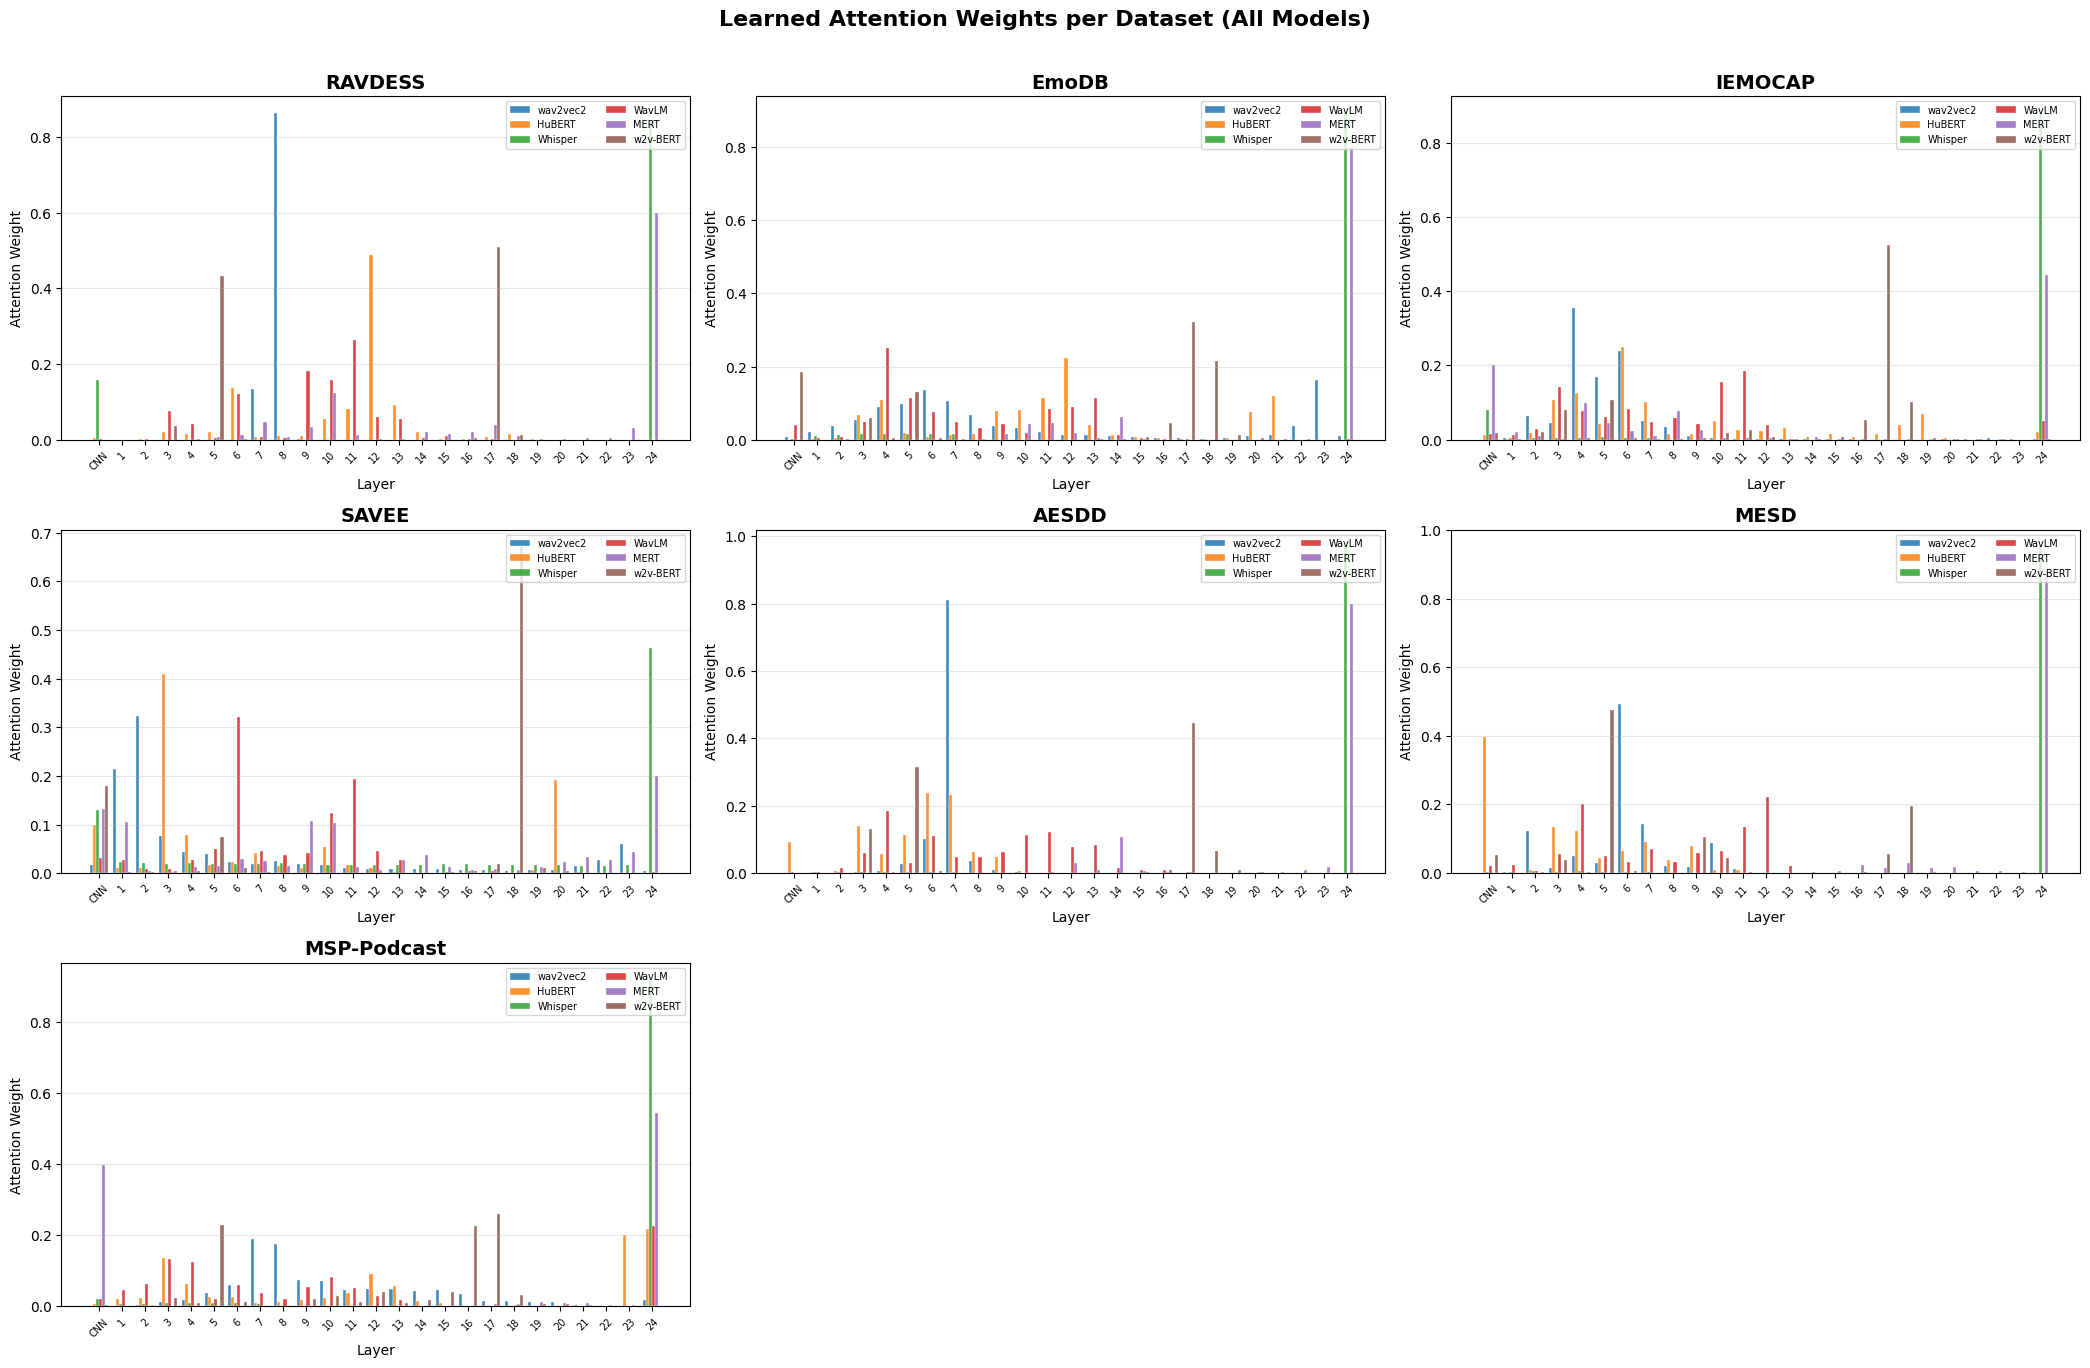

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/attention_bars_per_dataset.png


In [9]:
MODEL_COLORS = {
    'wav2vec2': '#1f77b4',
    'HuBERT':   '#ff7f0e',
    'Whisper':  '#2ca02c',
    'WavLM':    '#d62728',
    'MERT':     '#9467bd',
    'w2v-BERT': '#8c564b',
}

n_datasets = len(DATASETS)
# Layout: 7 datasets -> 3 rows x 3 cols (last two tiles hidden if fewer)
n_cols = 3
n_rows = int(np.ceil(n_datasets / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten()

x = np.arange(25)
bar_width = 0.8 / len(MODELS)

for d_idx, dataset in enumerate(DATASETS):
    ax = axes[d_idx]

    for m_idx, model in enumerate(MODELS):
        key = (model, dataset)
        if key in results:
            attn = results[key]['attention_weights']
            offset = (m_idx - len(MODELS) / 2 + 0.5) * bar_width
            ax.bar(x + offset, attn, bar_width,
                   label=model, color=MODEL_COLORS.get(model, '#333'),
                   alpha=0.85, edgecolor='white', linewidth=0.3)

    ax.set_title(f'{dataset}', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
    ax.set_xlabel('Layer', fontsize=10)
    ax.set_ylabel('Attention Weight', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(LAYER_LABELS, fontsize=7, rotation=45)
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.grid(True, alpha=PLOT_STYLE['grid_alpha'], axis='y')

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Learned Attention Weights per Dataset (All Models)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

bar_path = os.path.join(RESULTS_DIR, 'attention_bars_per_dataset.png')
plt.savefig(bar_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {bar_path}")


## 9. IEMOCAP Special Analysis: Acted vs Spontaneous

The frozen probing found that IEMOCAP (spontaneous speech) peaks at **Layer 1** while acted datasets peak at middle layers.  
Does the learned mixer confirm this? Compare IEMOCAP attention to the average of acted datasets (RAVDESS, EmoDB, SAVEE, AESDD, MESD).

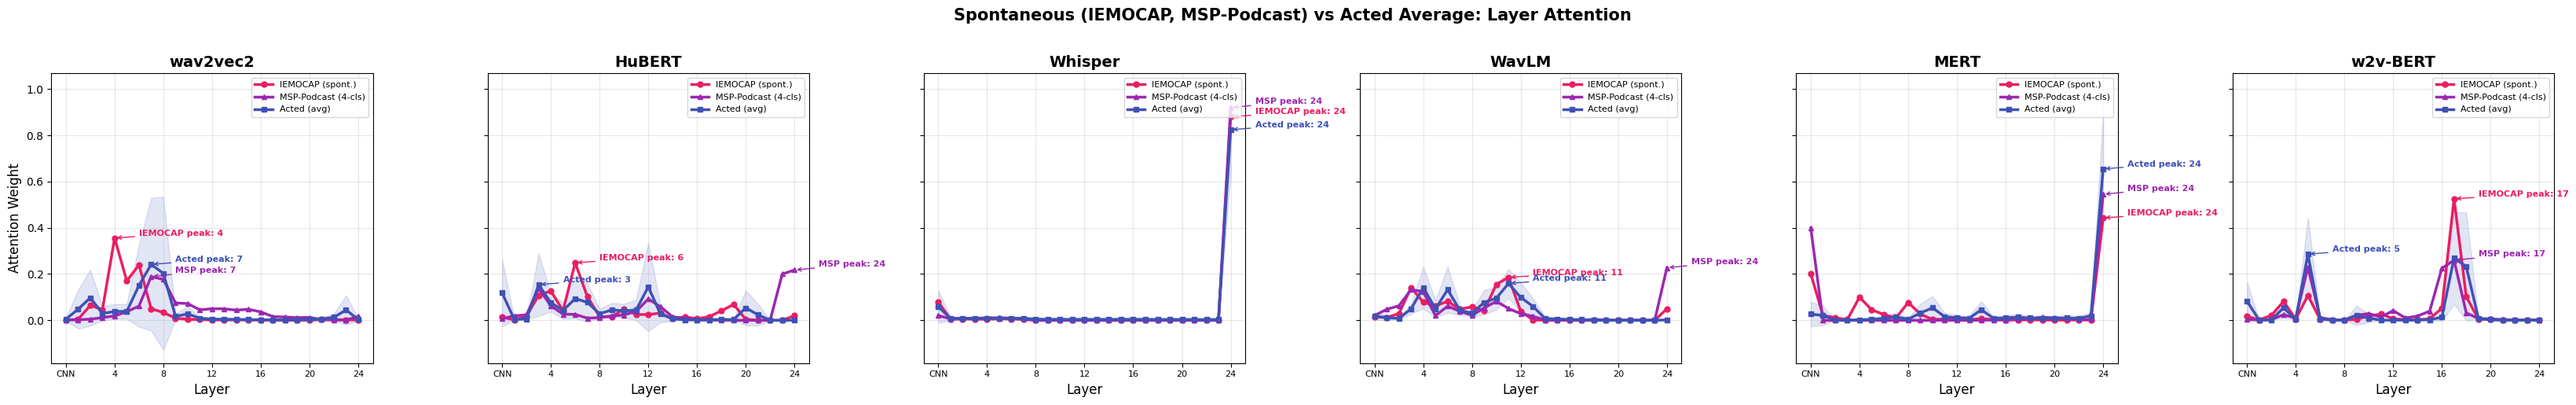

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/iemocap_msp_vs_acted_attention.png


In [10]:
# Acted datasets vs spontaneous (IEMOCAP) and in-the-wild podcast (MSP-Podcast)
ACTED_DATASETS = ['RAVDESS', 'EmoDB', 'SAVEE', 'AESDD', 'MESD']
SPONTANEOUS_DATASETS = ['IEMOCAP', 'MSP-Podcast']

fig, axes = plt.subplots(1, len(MODELS), figsize=(5.5 * len(MODELS), 5), sharey=True)
axes = np.array(axes).flatten() if len(MODELS) > 1 else [axes]

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    plotted_any = False

    # IEMOCAP (spontaneous dialogue)
    key = (model, 'IEMOCAP')
    if key in results:
        iemocap_attn = results[key]['attention_weights']
        ax.plot(range(25), iemocap_attn, marker='o', linewidth=2.5,
                color='#E91E63', label='IEMOCAP (spont.)', markersize=5)
        peak = int(np.argmax(iemocap_attn))
        ax.annotate(f'IEMOCAP peak: {LAYER_LABELS[peak]}',
                    xy=(peak, iemocap_attn[peak]),
                    xytext=(peak + 2, iemocap_attn[peak] + 0.01),
                    fontsize=8, fontweight='bold', color='#E91E63',
                    arrowprops=dict(arrowstyle='->', color='#E91E63'))
        plotted_any = True

    # MSP-Podcast (natural podcast recordings, 4-class)
    key = (model, 'MSP-Podcast')
    if key in results:
        msp_attn = results[key]['attention_weights']
        ax.plot(range(25), msp_attn, marker='^', linewidth=2.5,
                color='#9C27B0', label='MSP-Podcast (4-cls)', markersize=5)
        peak = int(np.argmax(msp_attn))
        ax.annotate(f'MSP peak: {LAYER_LABELS[peak]}',
                    xy=(peak, msp_attn[peak]),
                    xytext=(peak + 2, msp_attn[peak] + 0.015),
                    fontsize=8, fontweight='bold', color='#9C27B0',
                    arrowprops=dict(arrowstyle='->', color='#9C27B0'))
        plotted_any = True

    # Acted dataset average
    acted_attns = [results[(model, d)]['attention_weights']
                   for d in ACTED_DATASETS if (model, d) in results]
    if acted_attns:
        acted_mean = np.mean(acted_attns, axis=0)
        acted_std = np.std(acted_attns, axis=0)
        ax.plot(range(25), acted_mean, marker='s', linewidth=2.5,
                color='#3F51B5', label='Acted (avg)', markersize=5)
        ax.fill_between(range(25), acted_mean - acted_std, acted_mean + acted_std,
                        color='#3F51B5', alpha=0.15)
        peak_acted = int(np.argmax(acted_mean))
        ax.annotate(f'Acted peak: {LAYER_LABELS[peak_acted]}',
                    xy=(peak_acted, acted_mean[peak_acted]),
                    xytext=(peak_acted + 2, acted_mean[peak_acted] + 0.01),
                    fontsize=8, fontweight='bold', color='#3F51B5',
                    arrowprops=dict(arrowstyle='->', color='#3F51B5'))
        plotted_any = True

    ax.set_title(f'{model}', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
    ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
    if idx == 0:
        ax.set_ylabel('Attention Weight', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_xticks(range(0, 25, 4))
    ax.set_xticklabels([LAYER_LABELS[i] for i in range(0, 25, 4)], fontsize=8)
    if plotted_any:
        ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=PLOT_STYLE['grid_alpha'])

plt.suptitle('Spontaneous (IEMOCAP, MSP-Podcast) vs Acted Average: Layer Attention',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

iemocap_path = os.path.join(RESULTS_DIR, 'iemocap_msp_vs_acted_attention.png')
plt.savefig(iemocap_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {iemocap_path}")


## 10. Probing Accuracy Overlay with Attention Weights

For each model-dataset combo, overlay the frozen probing accuracy curve (from CSVs) with the learned attention weights (from LayerMixer). This directly shows whether the mixer "agrees" with the probing results about which layers carry the most emotion information.

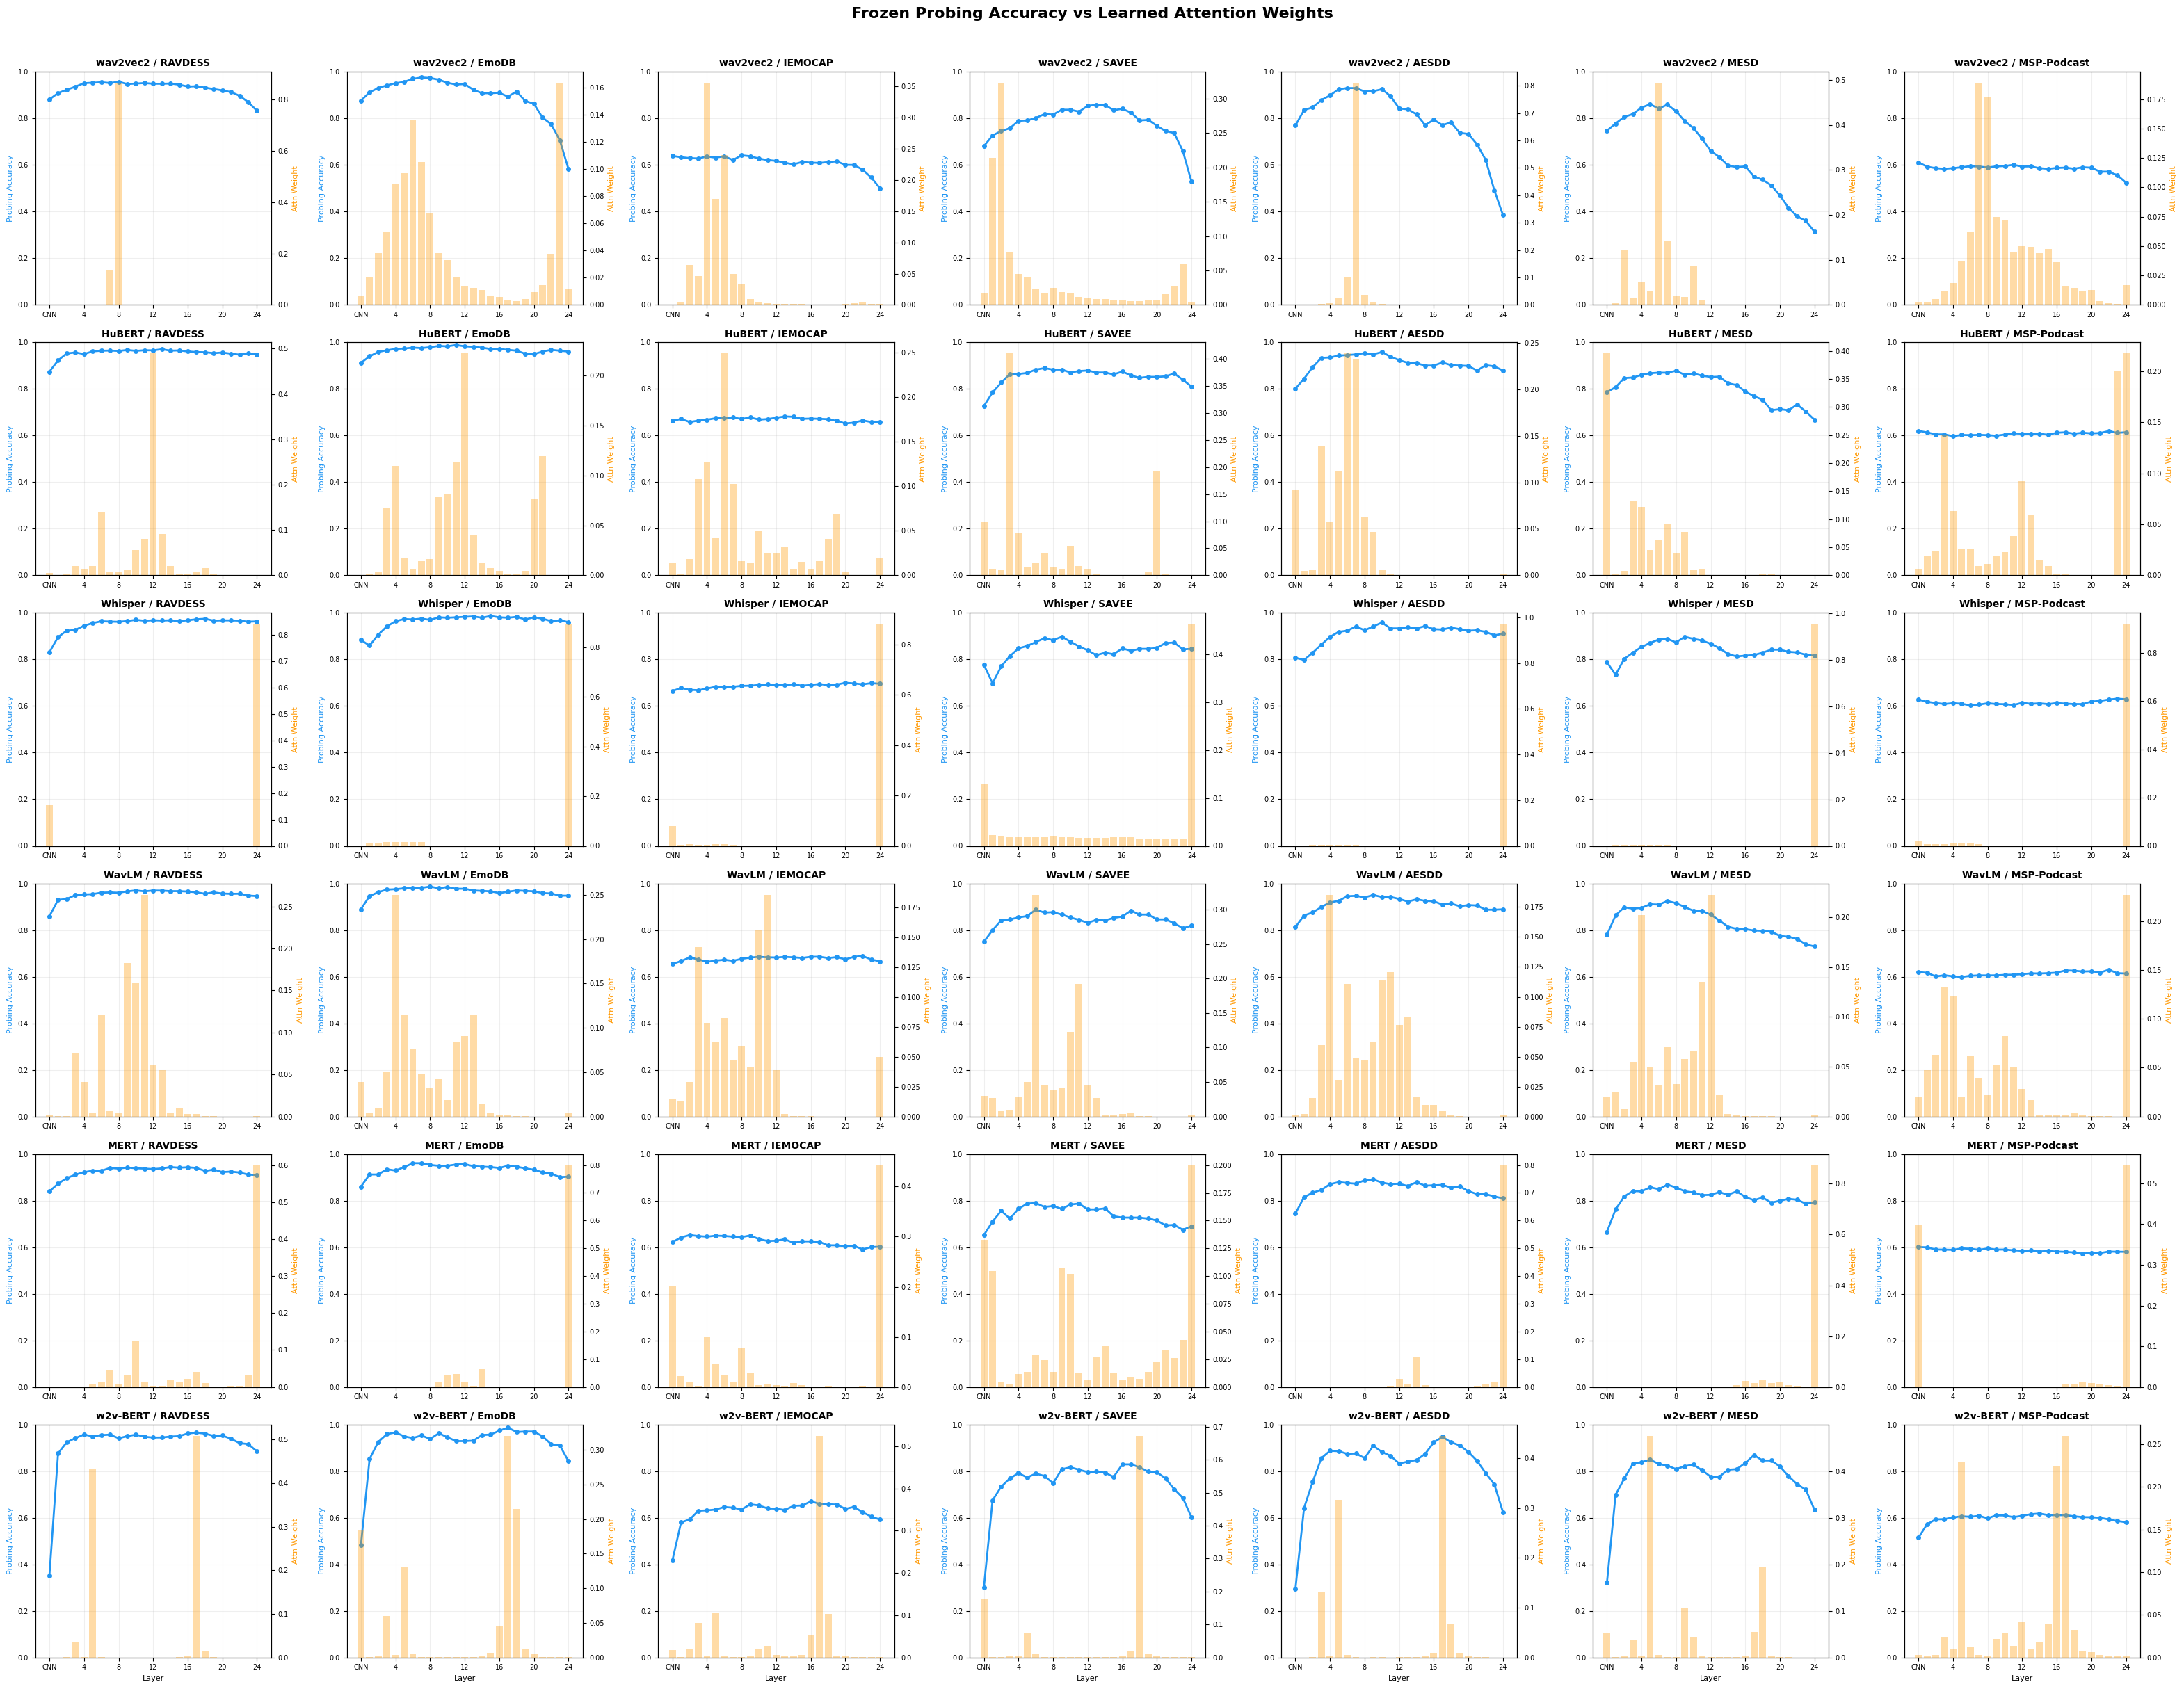

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/probing_vs_attention_overlay.png


In [11]:
n_rows = len(MODELS)
n_cols = len(DATASETS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows), squeeze=False)

for m_idx, model in enumerate(MODELS):
    for d_idx, dataset in enumerate(DATASETS):
        ax = axes[m_idx][d_idx]
        key = (model, dataset)
        
        has_data = False
        
        # Probing accuracy curve (left y-axis)
        if key in baseline:
            acc_curve = baseline[key]['all_acc']
            ax.plot(range(len(acc_curve)), acc_curve,
                    color=PLOT_STYLE['accuracy_color'], marker=PLOT_STYLE['accuracy_marker'],
                    linewidth=PLOT_STYLE['linewidth'], label='Probing Acc', markersize=4)
            ax.set_ylim([0, 1.0])
            ax.set_ylabel('Probing Accuracy', fontsize=8, color=PLOT_STYLE['accuracy_color'])
            has_data = True
        
        # Attention weights (right y-axis)
        if key in results:
            ax2 = ax.twinx()
            attn = results[key]['attention_weights']
            ax2.bar(range(25), attn, alpha=0.35, color='#FF9800', label='Attn Weight')
            ax2.set_ylabel('Attn Weight', fontsize=8, color='#FF9800')
            ax2.tick_params(axis='y', labelsize=7)
            has_data = True
        
        if has_data:
            ax.set_title(f'{model} / {dataset}', fontsize=10, fontweight='bold')
            ax.set_xticks(range(0, 25, 4))
            ax.set_xticklabels([LAYER_LABELS[i] for i in range(0, 25, 4)], fontsize=7)
            ax.tick_params(axis='y', labelsize=7)
            ax.grid(True, alpha=0.2)
        
        if m_idx == n_rows - 1:
            ax.set_xlabel('Layer', fontsize=8)

plt.suptitle('Frozen Probing Accuracy vs Learned Attention Weights',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

overlay_path = os.path.join(RESULTS_DIR, 'probing_vs_attention_overlay.png')
plt.savefig(overlay_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {overlay_path}")

## 11. Save All Results

Export attention weights matrix, per-experiment metrics, and a summary CSV to `my_code/results/layer_mixer/`.

In [12]:
# 1. Full attention weights matrix (for reuse by other notebooks)
attn_rows = []
for model in MODELS:
    for dataset in DATASETS:
        key = (model, dataset)
        if key in results:
            row = {'Model': model, 'Dataset': dataset}
            for i, label in enumerate(LAYER_LABELS):
                row[f'Layer_{label}'] = results[key]['attention_weights'][i]
            attn_rows.append(row)

attn_df = pd.DataFrame(attn_rows)
attn_path = os.path.join(RESULTS_DIR, 'attention_weights_all.csv')
attn_df.to_csv(attn_path, index=False)
print(f"Saved: {attn_path}")

# 2. Numpy archive for programmatic reuse
attn_dict = {}
for key, res in results.items():
    attn_dict[f'{key[0]}_{key[1]}'] = res['attention_weights']
np.savez(os.path.join(RESULTS_DIR, 'attention_weights.npz'), **attn_dict)
print(f"Saved: {os.path.join(RESULTS_DIR, 'attention_weights.npz')}")

# 3. Summary metrics CSV
summary_rows = []
for model in MODELS:
    for dataset in DATASETS:
        key = (model, dataset)
        if key in results:
            r = results[key]
            top_layer_idx = int(np.argmax(r['attention_weights']))
            summary_rows.append({
                'Model': model,
                'Dataset': dataset,
                'Mixer_Accuracy': r['mean_acc'],
                'Mixer_Std': r['std_acc'],
                'Mixer_F1': r['mean_f1'],
                'Top_Attn_Layer': LAYER_LABELS[top_layer_idx],
                'Top_Attn_Weight': r['attention_weights'][top_layer_idx],
                'Probe_Best_Acc': baseline.get(key, {}).get('best_acc', np.nan),
                'Probe_Best_Layer': baseline.get(key, {}).get('best_layer_name', ''),
            })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, 'layer_mixer_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")

# 4. List all saved files
print(f"\n{'='*60}")
print(f"All outputs in: {RESULTS_DIR}")
print(f"{'='*60}")
for f in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f:<45} {size_kb:>8.1f} KB")

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/attention_weights_all.csv
Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/attention_weights.npz
Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer/layer_mixer_summary.csv

All outputs in: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/layer_mixer
  attention_bars_per_dataset.png                   428.1 KB
  attention_heatmap_all_models.png                 330.5 KB
  attention_weights.npz                             14.8 KB
  attention_weights_all.csv                         13.7 KB
  iemocap_msp_vs_acted_attention.png               647.9 KB
  iemocap_vs_acted_attention.png                   379.9 KB
  layer_mixer_summary.csv                            4.3 KB
  mixer_vs_probing_comparison.csv                    3.6 KB
  probing_vs_attention_overlay.png                1675.4 KB
